In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q huggingface_hub

In [ ]:
import os
import shutil
from huggingface_hub import hf_hub_download
import pandas as pd

REPO_ID = "RadeAI/Digikala_comments_products"

products_path = hf_hub_download(repo_id=REPO_ID, filename="digikala-products.csv", repo_type="dataset")
comments_path = hf_hub_download(repo_id=REPO_ID, filename="digikala-comments.csv", repo_type="dataset")

drive_folder = '/content/drive/MyDrive/digikala_project'
os.makedirs(drive_folder, exist_ok=True)

shutil.copy(products_path, os.path.join(drive_folder, 'digikala-products.csv'))
shutil.copy(comments_path, os.path.join(drive_folder, 'digikala-comments.csv'))

print("Copied to :", drive_folder)

digikala-products.csv: reconstructing file:   0%|          |  0.00B /  259MB            

digikala-products.csv: downloading bytes:           |  0.00B            

digikala-comments.csv: reconstructing file:   0%|          |  0.00B / 1.28GB            

digikala-comments.csv: downloading bytes:           |  0.00B            

Copied to : /content/drive/MyDrive/digikala_project


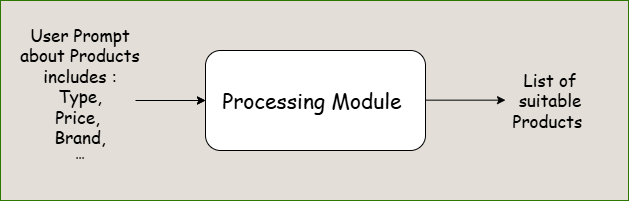

In [ ]:
# Next time
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
drive_folder = '/content/drive/MyDrive/digikala_project'

products = pd.read_csv(os.path.join(drive_folder, 'digikala-products.csv'))
comments = pd.read_csv(os.path.join(drive_folder, 'digikala-comments.csv'))

In [ ]:
print(products.head(3))
print("\n--- columns & nulls ---")
print(products.isnull().sum())
print("\n--- dtypes ---")
print(products.dtypes)

        id                         title_fa  Rate  Rate_cnt Category1  \
0  7096438     آبسلانگ مدل s5 بسته 250 عددی    90         4   آبسلانگ   
1  2845119    آبسلانگ مدل M-1 بسته 400 عددی    84       217   آبسلانگ   
2  6117745  آبسلانگ مدل m50 مجموعه 500 عددی    88        14   آبسلانگ   

  Category2   Brand   Price         Seller  Is_Fake  min_price_last_month  \
0       NaN  متفرقه  634800  سلامت ساز راد    False                     0   
1       NaN  متفرقه  818800      مهر افزون    False                     0   
2       NaN  متفرقه  920000         یانگوم    False                     0   

  sub_category  
0       beauty  
1       beauty  
2       beauty  

--- columns & nulls ---
id                           0
title_fa                     0
Rate                         0
Rate_cnt                     0
Category1                    0
Category2               210108
Brand                        0
Price                        0
Seller                     223
Is_Fake                   

In [ ]:
print(products['Category1'].value_counts().head(20))
print("\n---")
print(products['Category2'].value_counts().head(20))

Category1
اکسسوری زنانه و مردانه          95999
لباس زنانه                      93392
اسباب بازی                      92466
لباس مردانه                     68178
اکسسوری زنانه                   64470
اکسسوری مردانه                  49383
دخترانه                         42931
دفتر و کاغذ و مقوا              42864
زیورآلات طلا زنانه              41098
کتاب چاپی غیر فارسی             39409
مراقبت پوست                     29662
مواد غذایی                      28930
پسرانه                          27066
کتاب شعر و ادبیات               23345
برس‌ها و تجهیزات آرایشی         22749
محصولات سنگی، چینی و سرامیکی    22599
کفش مردانه                      20435
مد و پوشاک دخترانه و پسرانه     19861
کفش زنانه                       18396
نوزاد                           18324
Name: count, dtype: int64

---
Category2
فکری و آموزشی                   46767
دفتر                            38459
زیورآلات زنانه و مردانه         35086
لباس دخترانه                    26752
لباس ورزشی زنانه                23009

In [ ]:
# سلول ۴: تمیزکاری سریع و آماده‌سازی
import numpy as np

# محصولاتی که Rate_cnt خیلی کمه رو کنار نمی‌ذاریم ولی توی امتیازدهی جریمه می‌شن (پایین‌تر)

# پر کردن دسته‌بندی خالی برای جست‌وجوی متنی
products['Category2'] = products['Category2'].fillna('')
products['search_text'] = (
    products['title_fa'].astype(str) + ' ' +
    products['Category1'].astype(str) + ' ' +
    products['Category2'].astype(str) + ' ' +
    products['sub_category'].astype(str)
)

print(products['search_text'].head(3).tolist())

['آبسلانگ مدل s5 بسته 250 عددی آبسلانگ  beauty', ' آبسلانگ مدل M-1 بسته 400 عددی آبسلانگ  beauty', 'آبسلانگ مدل m50 مجموعه 500 عددی آبسلانگ  beauty']


In [ ]:
# سلول ۵: محاسبه‌ی امتیاز رضایت (Bayesian average)
# چرا Bayesian: محصولی با ۲ رأی و امتیاز ۱۰۰ نباید از محصولی با ۵۰۰۰ رأی و امتیاز ۹۵ بهتر باشه

C = products['Rate'].mean()          # میانگین کلی امتیاز همه‌ی محصولات
m = products['Rate_cnt'].quantile(0.6)  # حداقل تعداد رأی برای اعتماد کامل (قابل تنظیم)

def bayesian_score(row):
    v = row['Rate_cnt']
    R = row['Rate']
    return (v / (v + m)) * R + (m / (v + m)) * C

products['satisfaction_score'] = products.apply(bayesian_score, axis=1)

print("C (میانگین کلی):", C, "| m (آستانه):", m)
print(products[['title_fa','Rate','Rate_cnt','satisfaction_score']].sort_values('satisfaction_score', ascending=False).head(5))

/tmp/ipykernel_815/785987963.py:10: RuntimeWarning: invalid value encountered in scalar divide
  return (v / (v + m)) * R + (m / (v + m)) * C


C (میانگین کلی): 30.130309716586574 | m (آستانه): 0.0
                                                  title_fa  Rate  Rate_cnt  \
32            ژل ابرو شگلم مدل Set Me Up به همراه برس ابرو   100         3   
392720    کیف نوار بهداشتی مدل دختر و اسب تک شاخ کد IDM500   100         4   
1283185                   پاستیل ترکیبی نات لاین - 400 گرم   100         2   
1283187          شکلات ترافل میکس وانلی نات لاین - 325 گرم   100         3   
998203   کرم مرطوب کننده نیوآ مدل Chilled Oqsis حجم 100...   100         2   

         satisfaction_score  
32                    100.0  
392720                100.0  
1283185               100.0  
1283187               100.0  
998203                100.0  


In [ ]:
# سلول ۶: موتور جست‌وجوی TF-IDF (بدون LLM، بدون pytorch)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(max_features=50000)
tfidf_matrix = vectorizer.fit_transform(products['search_text'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (1283496, 50000)


In [ ]:
# سلول ۷: تابع اصلی جست‌وجو
def search_products(query, price_max=None, top_k=10,
                     w_semantic=0.5, w_satisfaction=0.5):
    # ۱. شباهت معنایی متنی با TF-IDF
    query_vec = vectorizer.transform([query])
    sim_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

    df = products.copy()
    df['semantic_score'] = sim_scores

    # ۲. فیلتر قیمت (اختیاری)
    if price_max is not None:
        df = df[df['Price'] <= price_max]

    # فقط محصولاتی که حداقل کمی شباهت متنی دارن رو نگه می‌داریم
    df = df[df['semantic_score'] > 0]

    if df.empty:
        return df

    # ۳. نرمال‌سازی امتیاز رضایت به بازه‌ی ۰ تا ۱ (چون Rate بین ۰-۱۰۰ است)
    df['satisfaction_norm'] = df['satisfaction_score'] / 100

    # ۴. ترکیب امتیازها
    df['final_score'] = (
        w_semantic * df['semantic_score'] +
        w_satisfaction * df['satisfaction_norm']
    )

    result = df.sort_values('final_score', ascending=False).head(top_k)
    return result[['id','title_fa','Category1','Category2','Price','Rate','Rate_cnt','final_score']]

In [ ]:
# سلول ۸: تست با مثال خود پروژه
result = search_products("کیف روزمره", price_max=1000000, top_k=10)
print(result)

               id                               title_fa       Category1  \
1251364   4892219            کفش روزمره مردانه مدل dm100      کفش مردانه   
198977    8407913              آویز کیف زنانه مدل KH1008   اکسسوری زنانه   
198944   11124369              کیف رودوشی زنانه مدل 2798   اکسسوری زنانه   
1251366   4892145            کفش روزمره مردانه مدل dl100      کفش مردانه   
1251368   4892393            کفش روزمره مردانه مدل az100      کفش مردانه   
321471    3340134               کیف کمری مردانه مدل B_10  اکسسوری مردانه   
143616    3658793  کیف لوازم آرایش زنانه مدل جغد کد A061   اکسسوری زنانه   
182699    2924455                 کیف پول زنانه کد 2-558   اکسسوری زنانه   
143636   11651697                 جاکارتی زنانه مدل 2863   اکسسوری زنانه   
898627    8526798                     کیف رودوشی مدل T-9       لوازم سفر   

                               Category2   Price  Rate  Rate_cnt  final_score  
1251364                کفش روزمره مردانه  992000    86       310     0.695235  
198

In [ ]:
# سلول ۹: تست دوم
result2 = search_products("وسیله کاربردی سفر", top_k=10)
print(result2)

              id                                           title_fa  \
548989   6175322                   برچسب طرح وسیله نقلیه کد A99-034   
1179454  7420742  کتاب جادوی مدیریت نیازمندی های مدیریت به وسیله...   
1187675   280006  کتاب آموزش کاربردی میکروتیک MTCRE اثر عاطفه شه...   
1185554  6414333  کتاب درمان بیماری ها به وسیله رنگها رنگ درمانی...   
1185553  6414333  کتاب درمان بیماری ها به وسیله رنگها رنگ درمانی...   
1188487  1701757       کتاب آموزش کاربردی FPGA اثر مهندس امیر عزیزی   
47788    7555097  بازی آموزشی انگلیسی اطلس آبی مدل وسیله نقلیه ک...   
111997   7555097  بازی آموزشی انگلیسی اطلس آبی مدل وسیله نقلیه ک...   
1186554  2549593  کتاب فلوئنت کاربردی اثر محمد گلشاهی فر انتشارا...   
1218764  8627543  کتاب 1/5 میلیارد وسیله حمل و نقل در جهان اثر ب...   

                                    Category1      Category2    Price  Rate  \
548989                     دفتر و کاغذ و مقوا           کاغذ   180000    94   
1179454                     کتاب علوم اجتماعی               

# Adding Embedding